# Diplomatura en Ciencia de Datos e Inteligencia Artificial en la Salud
## Facultad de Ciencias Médicas - UNC

### 📊 Proyecto: Predicción de Diabetes (CODIES I)
*Pipeline de Ciencia de Datos aplicado al análisis y modelado predictivo de factores de riesgo clínico.*

---

#### 👥 Integrante:
* **Basualdo, Jenifer Macarena**
---


# Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

## 1) Carga y calidad de los datos:

###  Carga del dataset

In [2]:
url = ' https://drive.google.com/uc?id=1gprgOJxPWWEnWNN2Yq9SaRSK3jhjAz4L' 

df = pd.read_stata (url)
df.head()

,id,sexo,edad,eciv,ni,fuma,hta,dlp,dbt,nes_cat3,...,estof,fritos,te,mate,caf,comidas,infusiones,sobrepeso,eent,obesidad
0,11.0,1.0,52.0,casado,2,0.0,1.0,1,1.0,2,...,6,3.0,0.0,28.0,0.00,3.0,28.000000,1,4.0,1.0
1,2982.0,2.0,45.0,separado,2,1.0,0.0,0,0.0,2,...,0,0.0,0.0,0.0,0.00,0.0,0.000000,0,4.0,0.0
2,1014.0,1.0,25.0,soltero,2,0.0,0.0,0,0.0,1,...,4,3.0,0.0,240.0,240.00,3.0,480.000000,0,3.0,0.0
3,2536.0,2.0,25.0,casado,2,0.0,0.0,0,0.0,2,...,0,4.0,0.0,1000.0,28.57,4.0,1028.569946,1,3.0,0.0
4,287.0,1.0,72.0,casado,1,0.0,0.0,0,0.0,1,...,4,4.0,0.0,0.0,0.00,0.0,0.000000,0,2.0,0.0


###  Observar dimensiones

In [3]:
df.shape

(4328, 91)

### Unidad de observación
¿Qué representa cada fila?
Se considera que cada fila corresponde a un caso dentro de la base, puesto que en la primera columna hay un código numérico de identificación 'único'. 

In [4]:
#Chequeamos si hay duplicados en los datos
df[df.duplicated(subset=['id'], keep=False)]

,id,sexo,edad,eciv,ni,fuma,hta,dlp,dbt,nes_cat3,...,estof,fritos,te,mate,caf,comidas,infusiones,sobrepeso,eent,obesidad
200,4223.0,2.0,82.0,casado,3,0.0,1.0,1,0.0,1,...,0,2.0,0.0,0.0,0.0,0.0,0.0,0,6.0,0.0
4327,4223.0,2.0,82.0,casado,3,0.0,1.0,1,0.0,1,...,0,2.0,0.0,0.0,0.0,0.0,0.0,0,6.0,0.0


A partir de los resultados arrojados, se observó que existen dos valores duplicados que, como se dijo inicialmente corresponden a los casos muestreados. Se toma la decisión de eliminar los casos duplicados. Por lo que el _n muestral_ queda reducido respecto al valor inicial. 


In [5]:
# Se elimina la fila duplicada
df.drop_duplicates(subset=['id'], keep = 'first') #Elijo quedarme con la primera fila de 'id' = 200

,id,sexo,edad,eciv,ni,fuma,hta,dlp,dbt,nes_cat3,...,estof,fritos,te,mate,caf,comidas,infusiones,sobrepeso,eent,obesidad
0,11.0,1.0,52.0,casado,2,0.0,1.0,1,1.0,2,...,6,3.0,0.0,28.0,0.00,3.0,28.000000,1,4.0,1.0
1,2982.0,2.0,45.0,separado,2,1.0,0.0,0,0.0,2,...,0,0.0,0.0,0.0,0.00,0.0,0.000000,0,4.0,0.0
2,1014.0,1.0,25.0,soltero,2,0.0,0.0,0,0.0,1,...,4,3.0,0.0,240.0,240.00,3.0,480.000000,0,3.0,0.0
3,2536.0,2.0,25.0,casado,2,0.0,0.0,0,0.0,2,...,0,4.0,0.0,1000.0,28.57,4.0,1028.569946,1,3.0,0.0
4,287.0,1.0,72.0,casado,1,0.0,0.0,0,0.0,1,...,4,4.0,0.0,0.0,0.00,0.0,0.000000,0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4322,4127.0,2.0,71.0,viudo,3,0.0,1.0,0,0.0,2,...,0,0.0,20.0,0.0,0.00,0.0,20.000000,1,6.0,1.0
4323,4154.0,2.0,64.0,casado,1,0.0,0.0,1,0.0,1,...,2,0.0,20.0,0.0,10.00,0.0,30.000000,1,2.0,0.0
4324,4269.0,2.0,58.0,casado,3,0.0,0.0,0,0.0,3,...,8,0.0,0.0,0.0,0.00,0.0,0.000000,0,6.0,0.0
4325,4229.0,2.0,65.0,casado,3,0.0,0.0,0,0.0,2,...,0,0.0,0.0,0.0,0.00,0.0,0.000000,1,6.0,0.0


## Elección de problemática de interés: 

Se decidió trabajar sobre la 'diabetes' como problemática. Para ello se incursiona sobre todas las variables existentes y se eligen aquellas que más resultan de interés. 

In [6]:
# Se ven las variables
df.columns.to_list()

['id',
 'sexo',
 'edad',
 'eciv',
 'ni',
 'fuma',
 'hta',
 'dlp',
 'dbt',
 'nes_cat3',
 'peso',
 'talla',
 'circcint',
 'grasa',
 'pd1',
 'ps1',
 'ps2',
 'pd2',
 'psm',
 'pdm',
 'ecar',
 'ic',
 'htamed',
 'cancer',
 'tummal',
 'tumben',
 'ubic',
 'ctosdiafuma',
 'mets',
 'mets_cat',
 'sedentario',
 'vet',
 'hc',
 'pr',
 'gr',
 'agsat',
 'agin',
 'agp',
 'agm',
 'colesterol',
 'fibratotal',
 'fibrasol',
 'fibrainsol',
 'sodio',
 'lact',
 'que',
 'hue',
 'car',
 'cab',
 'cac',
 'vis',
 'fiem',
 'vega',
 'vegb',
 'vegc',
 'frua',
 'frub',
 'frus',
 'frud',
 'cere',
 'leg',
 'pan',
 'gal',
 'past',
 'dulc',
 'gol',
 'azuc',
 'edulc',
 'aceite',
 'mant',
 'ader',
 'hel',
 'agua',
 'jugo',
 'gas',
 'alco',
 'cpre',
 'crap',
 'snac',
 'tort',
 'salt',
 'estof',
 'fritos',
 'te',
 'mate',
 'caf',
 'comidas',
 'infusiones',
 'sobrepeso',
 'eent',
 'obesidad']

Acorde a variables vistas, se crea un nuevo Dataframe pero esta vez solo teniendo en cuenta las variables con las que se decide trabajar. Las mismas son:

- Sexo, edad
- Diabetes 
- Peso y talla
- Circunferencia de cintura
- Sedentario
- Alcohol
- Colesterol
- Cáncer
- Azúcar

In [7]:
df_nuevo = df[['id', 'sexo', 'edad', 'dbt', 'peso', 'talla', 'circcint', 'sedentario', 'colesterol', 'alco', 'cancer']]
df_nuevo.head(20)

,id,sexo,edad,dbt,peso,talla,circcint,sedentario,colesterol,alco,cancer
0,11.0,1.0,52.0,1.0,115.099998,1.82,120.000000,0,281.089996,83.330002,0.0
1,2982.0,2.0,45.0,0.0,68.699997,1.70,69.000000,1,266.230011,5.330000,0.0
2,1014.0,1.0,25.0,0.0,65.199997,1.74,78.000000,0,163.279999,0.000000,0.0
3,2536.0,2.0,25.0,0.0,80.199997,1.68,85.000000,0,245.369995,71.419998,0.0
4,287.0,1.0,72.0,0.0,73.099998,1.74,88.000000,0,115.660004,0.000000,0.0
5,1040.0,1.0,23.0,0.0,87.199997,1.78,90.000000,1,279.029999,10.700000,0.0
6,1815.0,1.0,58.0,0.0,104.000000,1.83,98.000000,0,568.010010,53.299999,0.0
7,2107.0,2.0,29.0,0.0,55.000000,1.55,85.000000,0,318.049988,0.000000,0.0
8,878.0,1.0,33.0,0.0,75.000000,1.80,83.199997,1,331.459991,17.309999,0.0
9,3317.0,2.0,43.0,0.0,67.199997,1.56,86.000000,0,348.089996,0.000000,0.0


### Limpieza de datos

#### Tipo de datos 
Se documentan los datos asignados por defecto.

In [8]:
df_nuevo.info()

<class 'pandas.DataFrame'>
RangeIndex: 4328 entries, 0 to 4327
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          4328 non-null   float64
 1   sexo        4327 non-null   float64
 2   edad        4326 non-null   float64
 3   dbt         4323 non-null   float64
 4   peso        4328 non-null   float32
 5   talla       4328 non-null   float32
 6   circcint    4328 non-null   float32
 7   sedentario  4328 non-null   int8   
 8   colesterol  4327 non-null   float32
 9   alco        4328 non-null   float32
 10  cancer      4327 non-null   float64
dtypes: float32(5), float64(5), int8(1)
memory usage: 257.9 KB


Se ve que hay variables que presentan distintos 'tipos de dato' asignados por defecto como así también se observan valores 'nulos/faltantes'; sin embargo, en pasos posteriores se debe realizar la transformación correspondiente.

### Elección de 5 variables para exploración


In [9]:
df_nuevo = df_nuevo[['id', 'sexo', 'edad', 'dbt', 'peso', 'talla', 'sedentario', 'colesterol']]
df_nuevo

,id,sexo,edad,dbt,peso,talla,sedentario,colesterol
0,11.0,1.0,52.0,1.0,115.099998,1.82,0,281.089996
1,2982.0,2.0,45.0,0.0,68.699997,1.70,1,266.230011
2,1014.0,1.0,25.0,0.0,65.199997,1.74,0,163.279999
3,2536.0,2.0,25.0,0.0,80.199997,1.68,0,245.369995
4,287.0,1.0,72.0,0.0,73.099998,1.74,0,115.660004
...,...,...,...,...,...,...,...,...
4323,4154.0,2.0,64.0,0.0,65.500000,1.56,1,365.239990
4324,4269.0,2.0,58.0,0.0,60.500000,1.64,0,256.079987
4325,4229.0,2.0,65.0,0.0,79.000000,1.68,1,334.589996
4326,4132.0,2.0,38.0,0.0,59.000000,1.65,1,198.009995


In [10]:
df_nuevo.describe()

,id,sexo,edad,dbt,peso,talla,sedentario,colesterol
count,4328.000000,4327.000000,4326.000000,4323.000000,4328.000000,4328.000000,4328.000000,4327.000000
mean,2164.666128,1.578692,42.705964,0.061069,71.952255,1.894732,0.324399,354.263000
std,1249.756218,0.510399,18.027416,0.239484,15.159122,6.133593,0.468204,179.407745
min,1.000000,1.000000,3.000000,0.000000,39.500000,1.390000,0.000000,1.250000
25%,1082.750000,1.000000,26.000000,0.000000,60.299999,1.600000,0.000000,236.654999
50%,2164.500000,2.000000,41.000000,0.000000,70.300003,1.660000,0.000000,321.670013
75%,3246.250000,2.000000,57.000000,0.000000,81.199997,1.730000,1.000000,434.559998
max,4328.000000,10.000000,98.000000,1.000000,184.000000,176.000000,1.000000,3340.899902


Mediante esa descripción ya se pueden observar algunas inconsistencias. En la variable 'sexo' que toma valores '1' o '2' se ve que existe un valor máximo de '10'.
Algo similar con el atributo 'edad', donde inicialmente se informó que los individuos tenían más de 18 años pero acorde a esa descripción hay una edad de '3' años. 
El campo de 'talla' presenta errores de unidades, parece ser que hay valores puestos en centímtros y otros en metros. 
Del mismo modo, en 'colesterol' se observa un min de 1.25 y un máx de 3340 datos que biologicamente son imposibles.

Todas estas observaciones serán tenidas en cuenta en pasos posteriores.

### Visualización de variables
El objetivo de la visualización es observar si existen valores imposibles, errores de carga o alguna otra inconsistencia que luego requieran de alguna limpieza.

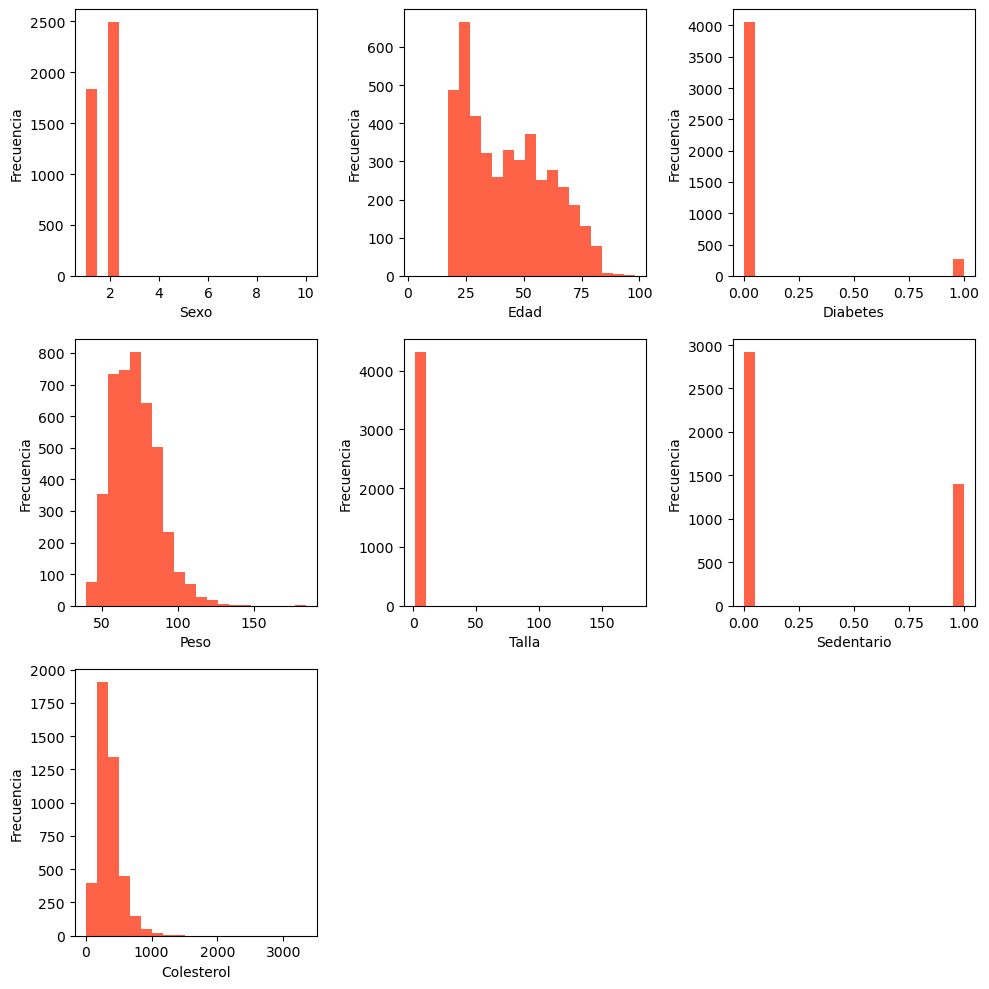

In [11]:
# Visualización mediante histrograma
plt.figure(figsize=(10,10))

plt.subplot(331)
plt.hist(df_nuevo['sexo'], bins = 20, color='tomato')
plt.xlabel ('Sexo')
plt.ylabel('Frecuencia')

plt.subplot(332)
plt.hist(df_nuevo['edad'], bins = 20, color='tomato')
plt.xlabel ('Edad')
plt.ylabel('Frecuencia')

plt.subplot(333)
plt.hist(df_nuevo['dbt'], bins = 20, color='tomato')
plt.xlabel ('Diabetes')
plt.ylabel('Frecuencia')

plt.subplot(334)
plt.hist(df_nuevo['peso'], bins = 20, color='tomato')
plt.xlabel ('Peso')
plt.ylabel('Frecuencia')

plt.subplot(335)
plt.hist(df_nuevo['talla'], bins = 20, color='tomato')
plt.xlabel ('Talla')
plt.ylabel('Frecuencia')

plt.subplot(336)
plt.hist(df_nuevo['sedentario'], bins = 20, color='tomato')
plt.xlabel ('Sedentario')
plt.ylabel('Frecuencia')

plt.subplot(337)
plt.hist(df_nuevo['colesterol'], bins = 20, color='tomato')
plt.xlabel ('Colesterol')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Los histogramas anteriores sirven para observar la existencia de puntaciones extremas como así también ver si la distribución de las distintas variables se amolda a una _normal._

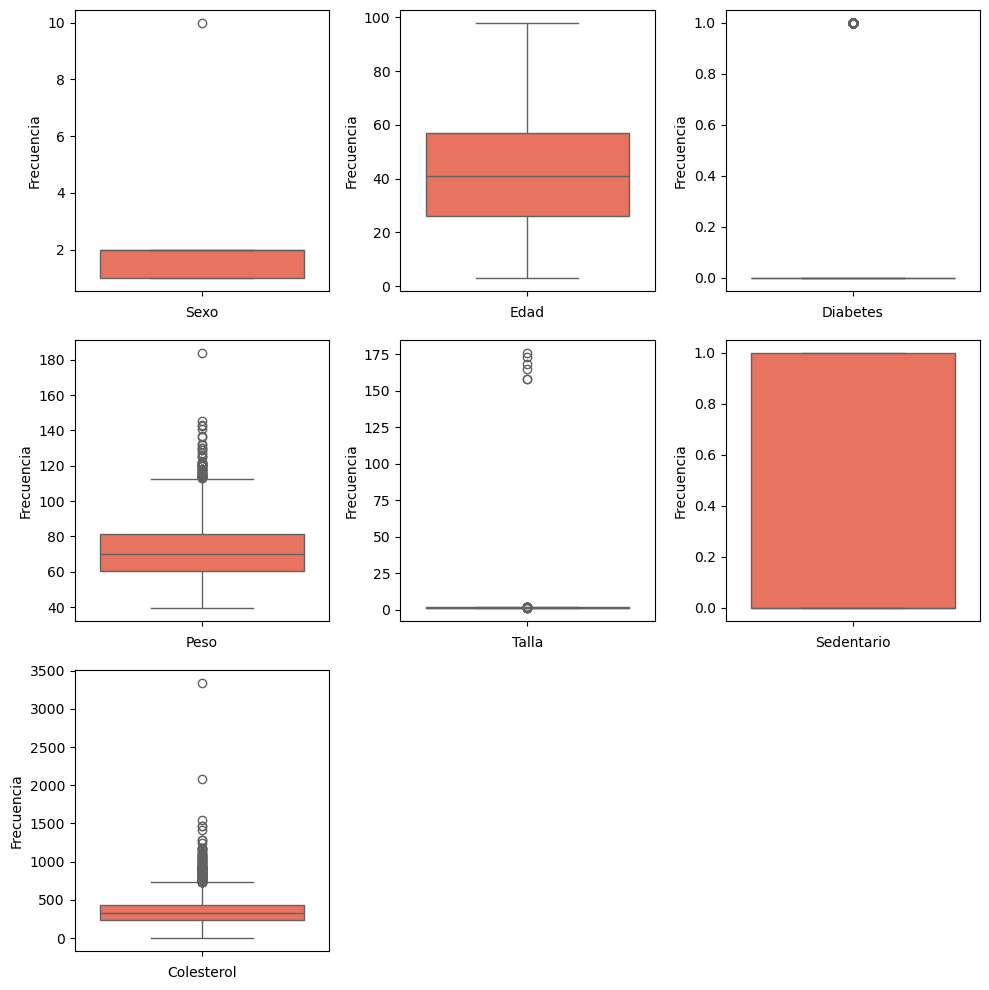

In [12]:
# Visualización mediante boxplot
plt.figure(figsize=(10,10))

plt.subplot(331)
sns.boxplot (df_nuevo['sexo'], color='tomato')
plt.xlabel ('Sexo')
plt.ylabel('Frecuencia')

plt.subplot(332)
sns.boxplot (df_nuevo['edad'], color='tomato')
plt.xlabel ('Edad')
plt.ylabel('Frecuencia')

plt.subplot(333)
sns.boxplot (df_nuevo['dbt'], color='tomato')
plt.xlabel ('Diabetes')
plt.ylabel('Frecuencia')

plt.subplot(334)
sns.boxplot (df_nuevo['peso'], color='tomato')
plt.xlabel ('Peso')
plt.ylabel('Frecuencia')

plt.subplot(335)
sns.boxplot (df_nuevo['talla'], color='tomato')
plt.xlabel ('Talla')
plt.ylabel('Frecuencia')

plt.subplot(336)
sns.boxplot (df_nuevo['sedentario'], color='tomato')
plt.xlabel ('Sedentario')
plt.ylabel('Frecuencia')

plt.subplot(337)
sns.boxplot (df_nuevo['colesterol'], color='tomato')
plt.xlabel ('Colesterol')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

- _VARIABLE:_ Sexo

Se observan que los valores en general toman 1 o 2. Sin embargo, existe un valor atípico de 10 y, como se trata de solo **UNO**  se presume que se trata de un error de tipeo. 

Decisión futura: por la gran cantidad de casos, se considera que es mejor eliminar el caso para evitar posibles sesgos en futuros análisis.

- _VARIABLE:_ Edad

A pesar de no identificarse valores extremos, en la información brindaba se aclaró que la pobablación tenía más de 18 años.

Decisión futura: Todos aquellos casos donde los individuos tienen menos de 18 años quedan excluídos. 

- _VARIABLE:_ Diabetes

No se observan anomalías.

- _VARIABLE:_ Peso

La caja es "pesada en la parte inferior", y hay una larga serie de valores atípicos en la parte superior. Esto indica que mientras la mayoría de los pacientes están en el rango de 60–80 kg, existe un subgrupo significativo de pacientes con pesos mucho más altos. Incluso hay un valor atípico "extremo" de 184 kg, que puede representar a un paciente real o un error de medición.

Decisión futura: Excluir ese outlier o rellenarlo con la media.

- _VARIABLE:_ Talla

En este atributo se observan valores o muy cercanos a 1 (parte inferior acumulada puesto a que hay valores representados en metros) y valores muy altos +150 (valores que deben estar tipeados en centímetros).

Decisión futura: Realizar una corrección de unidades.

- _VARIABLE:_ Colesterol

La mayoría de los individuos tienen niveles de colesterol entre aproximadamente 250 y 450 mg/dL. La mediana se sitúa alrededor de 350. El bigote inferior baja cerca de cero (lo cual es biológicamente imposible para un ser humano vivo—una gran señal de alerta), y el bigote superior se detiene alrededor de 750.
El "Grupo de Valores Atípicos": Hay un enorme y denso grupo de valores atípicos entre 750 y 1500.
Valores Atípicos Extremos: Hay dos puntos muy distintos situados en ~2100 y uno enorme en ~3300. Lo mismo sucede con aquellos valores mínimos.

Decisión futura: 
Excluir aquellos valores que esten por encima de 880 mg/dL según fuentes bibliográficas.

### Tratamiento de outliers

#### Variable: Sexo

In [13]:
#El valor atípico de 10 observado, se elimina de la base
df_nuevo = df_nuevo[df_nuevo['sexo'] < 10 ]
df_nuevo['sexo'].min()

1.0

#### Variable: Edad

In [14]:
# Todos aquellos casos donde los individuos tienen menos de 18 años quedan excluídos.
df_nuevo = df_nuevo[df_nuevo['edad'] >= 18 ]
df_nuevo['edad'].min()

18.0

#### Variable: Peso

In [15]:
# A simple viste el outlier observado puede ser un caso real
df_nuevo.loc[df_nuevo['peso'] == 184, 'talla']


3416    1.97
Name: talla, dtype: float32

Si bien ese caso podría ser real, su puntuación extrema como se observa en el boxplot podría influir sobre el resto de los valores. Por lo que, al tratarse solo de un caso se decide excluir el punto en cuestión.

In [16]:
df_nuevo = df_nuevo[df_nuevo['peso'] < 184]
df_nuevo['peso'].max() #Chequeo si desapareció ese valor

145.5

#### Variable: Talla

In [17]:
#Pasamos los valores que se encuentra en centímetros a metros
df_nuevo.loc[df_nuevo['talla'] > 150 , 'talla'] = df_nuevo [ 'talla' ] / 100
df_nuevo ['talla'].max()

1.9800000190734863

#### Variable: Diabetes
##### Tratamiento de valores altos
**El colesterol se mide en miligramos (mg) por decilitro (dL) de sangre. Se considera que un nivel inferior a 200 mg/dL (5,2 mmol/L) es óptimo. Valores comprendidos entre 200 y 239 mg/dL (5,2–6,2 mmol/L) se clasifican como moderadamente elevados, mientras que niveles iguales o superiores a 240 mg/dL (6,3 mmol/L) se asocian con un alto riesgo. El colesterol total se obtiene a partir de la suma de las concentraciones de lipoproteínas de alta densidad (HDL) y lipoproteínas de baja densidad (LDL)** (Dritsas  & Trigka, 2022; Ford et al., 2003).

Sin embargo, otras fuentes indican que existen casos extremos donde los valores pueden llegar a un máximo de 880 mg/dL.
(Nordestgaard et al., 2016).

##### Tratamiento de valores mínimos
**Actualmente existen fármacos (estatinas, ezetimiba e inhibidores de PCSK9) que permiten reducir el colesterol LDL (LDL-C) a niveles sin precedentes. Se espera que con los mismos un número creciente de pacientes alcance valores muy bajos de LDL-C (<30 mg/dL).** (Karagiannis et al., 2021).


_Referencias bibliográficas_
- Ford, E.S., Mokdad, A.H., Giles, W.H., & Mensah, G.A. (2003). Serum Total Cholesterol Concentrations and Awareness, Treatment, and Control of Hypercholesterolemia Among US Adults: Findings From the National Health and Nutrition Examination Survey, 1999 to 2000. Circulation: Journal of the American Heart Association, 107, 2185-2189.10.1161/01.CIR.0000066320.27195.B4
- Dritsas, E., & Trigka, M. (2022). Machine Learning Methods for Hypercholesterolemia Long-Term Risk Prediction. Sensors (Basel, Switzerland), 22.https://doi.org/10.3390/s22145365
- Nordestgaard, B.G., Langsted, A., Mora, S., Kolovou, G., Baum, H., Bruckert, E., Watts, G.F., Sypniewska, G., Wiklund, O., Borén, J., Chapman, M.J., Cobbaert, C.M., Descamps, O.S., von Eckardstein, A., Kamstrup, P.R., Pulkki, K., Kronenberg, F., Remaley, A., Rifai, N., Ros, E., & Langlois, M.R. (2016). Fasting is not routinely required for determination of a lipid profile: clinical and laboratory implications including flagging at desirable concentration cut-points—a joint consensus statement from the European Atherosclerosis Society and European Federation of Clinical Chemistry and Laboratory Med. European Heart Journal, 37, 1944 - 1958. https://doi.org/10.1093/eurheartj%2Fehw152
- Karagiannis, A. D., Mehta, A., Dhindsa, D. S., Virani, S. S., Orringer, C. E., Blumenthal, R. S., Stone, N. J., & Sperling, L. S. (2021). How low is safe? The frontier of very low (<30 mg/dL) LDL cholesterol. European heart journal, 42(22), 2154–2169. https://doi.org/10.1093/eurheartj/ehaa1080


In [18]:
#Se excluyen todos aquellos valores mayores a 880 mg/dL
df_nuevo = df_nuevo[df_nuevo['colesterol'] <= 880]
df_nuevo['colesterol'].max()

877.260009765625

In [19]:
#Observo los mínimos
df_nuevo['colesterol'].sort_values().head(20)

238      1.250000
656     12.890000
2457    18.530001
1144    29.200001
2997    33.340000
3696    37.770000
4165    37.950001
2666    40.799999
165     40.970001
2461    43.650002
3637    45.299999
224     48.709999
3671    50.150002
4185    51.570000
1486    55.740002
3208    55.779999
613     55.900002
356     56.230000
3349    57.720001
3346    58.730000
Name: colesterol, dtype: float32

In [20]:
# Acorde a la bibliografía se eliminan todos aquellos casos cuyos valores son menores a 30 mg/dL
df_nuevo = df_nuevo[df_nuevo['colesterol'] >= 30 ]
df_nuevo['colesterol'].sort_values().head(5)

2997    33.340000
3696    37.770000
4165    37.950001
2666    40.799999
165     40.970001
Name: colesterol, dtype: float32

/tmp/ipykernel_49/2265794695.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_nuevo, y = col , palette = ['tomato'])
/tmp/ipykernel_49/2265794695.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_nuevo, y = col , palette = ['tomato'])
/tmp/ipykernel_49/2265794695.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_nuevo, y = col , palette = ['tomato'])
/tmp/ipykernel_49/2265794695.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

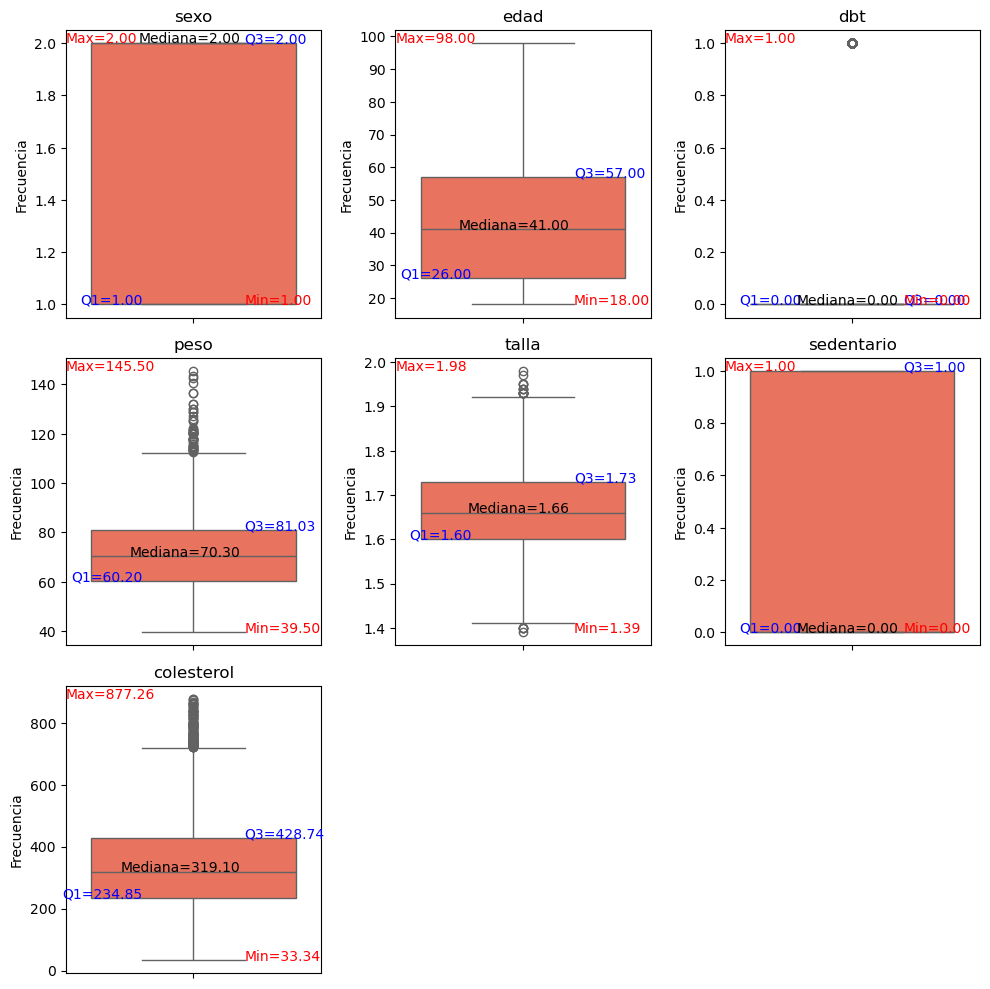

In [21]:
# Visualización mediante boxplot
plt.figure(figsize=(10,10))

cols = ['sexo', 'edad', 'dbt', 'peso', 'talla', 'sedentario','colesterol'  ] 

for i, col in enumerate (cols): 
    plt.subplot(3, 3, i+1)
    sns.boxplot(data = df_nuevo, y = col , palette = ['tomato'])
    plt.title (f'{col}')
    plt.ylabel('Frecuencia')

# Calcular estadísticas
    data = df_nuevo[col].dropna()
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    median = np.median(data)
    min_val = np.min(data)
    max_val = np.max(data)

    # Añadir etiquetas con desplazamiento horizontal (x=0.15)
    plt.text(-0.2, q1, f'Q1={q1:.2f}', color='blue', ha='right')
    plt.text(0.2, q3, f'Q3={q3:.2f}', color='blue', ha='left')
    plt.text(0.183, median, f'Mediana={median:.2f}', color='black', ha='right')
    plt.text(0.2, min_val, f'Min={min_val:.2f}', color='red', ha='left')
    plt.text(-0.5, max_val, f'Max={max_val:.2f}', color='red', ha='left')
    
plt.tight_layout()
plt.show()

### Creación de una nueva variable

Se calculará el ïndice de Masa Corporal (IMC) cuya fórmula es (peso / talla **2). Para clasificar el IMC se utilizó la categorización desarrollada por Nam et al. (2021) la cual se distribuye en siete niveles distintos: 

    - 'Bajo peso': inferior a 18.5
    
    - 'Normal': entre 18.5 y 24.9
    
    - 'Sobrepeso Grado 1': entre 25 y 29,9
    
    - 'Sobrepeso Grado 2': entre 30 y 34,9
    
    - 'Obesidad tipo 1': entre 35 y 39,9
    
    - 'Obesidad tipo 2': entre  40 y 44,9
    
    - 'Obesidad tipo 3': Superior a 45.0

Esta clasificación le posibilita al profesional de la salud conocer los riesgos potenciales en función de la categoría a la que pertenece el paciente y, a partir de ello tomar la decisión terapéutica más adecuada para mejorar la calidad de vida y disminuir riesgos en la salud (cardiopatícas, cambios metabólicos, mortalidad, etc.)

_Referencias Bibliográficas_

- Nam, G. E., Kim, Y. H., Han, K., Jung, J. H., Rhee, E. J., Lee, W. Y., & Obesity Fact Sheet of the Korean Society for the Study of Obesity (2021). Obesity Fact Sheet in Korea, 2020: Prevalence of Obesity by Obesity Class from 2009 to 2018. Journal of obesity & metabolic syndrome, 30(2), 141–148. https://doi.org/10.7570/jomes21056


In [22]:
#Cálculo del imc
df_nuevo['imc'] = df_nuevo['peso'] / (df_nuevo ['talla']**2)
df_nuevo[['peso', 'imc']]

,peso,imc
0,115.099998,34.748219
1,68.699997,23.771624
2,65.199997,21.535208
3,80.199997,28.415533
4,73.099998,24.144537
...,...,...
4323,65.500000,26.914862
4324,60.500000,22.494051
4325,79.000000,27.990364
4326,59.000000,21.671259


In [23]:
print(f'Media: {df_nuevo['imc'].mean() } ')
print(f'Desvio estándar: {df_nuevo['imc'].std()} ')
print(f'Mínimo: {df_nuevo['imc'].min()} ')
print(f'Máximo: {df_nuevo['imc'].max()} ')

Media: 25.848390579223633 
Desvio estándar: 4.7976393699646 
Mínimo: 14.764616012573242 
Máximo: 51.11111068725586 


In [24]:
# Creación de imc_categoria
condiciones = [
    (df_nuevo['imc'] < 18.5), 
    (df_nuevo['imc'] >= 18.5) & (df_nuevo['imc'] <= 24.9),
    (df_nuevo['imc'] >= 25.0) & (df_nuevo['imc'] <= 29.9),
    (df_nuevo['imc'] >= 30.0) & (df_nuevo['imc'] <= 34.9),
    (df_nuevo['imc'] >= 35.0) & (df_nuevo['imc'] <= 39.9),
    (df_nuevo['imc'] >= 40.0) & (df_nuevo['imc'] <= 44.9),
    (df_nuevo['imc'] >= 45.0)
]

categorias = [
    'Bajo peso', 
    'Normal', 
    'Sobrepeso Grado 1', 
    'Sobrepeso Grado 2', 
    'Obesidad tipo 1', 
    'Obesidad tipo 2', 
    'Obesidad tipo 3'
]

df_nuevo['imc_categoria'] = np.select(condiciones, categorias, default='Otro')

# Verificar resultado
df_nuevo[['imc','imc_categoria']].head()


,imc,imc_categoria
0,34.748219,Sobrepeso Grado 2
1,23.771624,Normal
2,21.535208,Normal
3,28.415533,Sobrepeso Grado 1
4,24.144537,Normal


In [25]:

df_nuevo['imc_categoria'].value_counts()


imc_categoria
Normal               1959
Sobrepeso Grado 1    1440
Sobrepeso Grado 2     520
Obesidad tipo 1       142
Bajo peso              78
Otro                   67
Obesidad tipo 2        41
Obesidad tipo 3        13
Name: count, dtype: int64

In [26]:
# Crear figura y gráfico
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df_nuevo, 
                   x='imc_categoria', 
                   order=orden_categorias, 
                   palette='Reds')

# Añadir valores sobre cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}",   # frecuencia absoluta
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

# Ajustes finales
plt.title('Distribución de categorías de IMC')
plt.xlabel('Categoría IMC')
plt.ylabel('Frecuencia')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


NameError: name 'orden_categorias' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
 #visualización completa de la tabla
df_nuevo

### 2) Gestión de datos faltantes (Missing Data):

In [ ]:
df_nuevo.info () 

In [ ]:
df_nuevo.shape

Teniendo en cuenta que, el nuevo Dataframe creado tiene una dimension de (4260, 10), se observa que solo en la variable 3 correspondiente a diabetes 'dbt' se presentan 4255 datos _no nulos._ Esto indica que existen 5 valores que son faltantes o son nulos (NAN).

### Detectar valores faltantes

In [ ]:
df_nuevo['dbt'].isnull().sum() #observo la cantidad

In [ ]:
df_nuevo[df_nuevo['dbt'].isnull()].index #obtengo el índice  

In [ ]:
df_nuevo.loc[[154, 156, 159, 168, 2977], 'dbt' ] #observo cómo están presentados esos valores

In [ ]:
#observo la frecuencia de los valores
df_nuevo['dbt'].value_counts()

Debido a que la variable es de tipo nominal dicotómica, se selecciona el método de imputación por medida de tendencia central dentro de las cuales se elije la _moda_ por ser la función estadística posible para este nivel de medición de la variable 'diabetes' (dbt). Por tanto, al trabajar con este tipo de variables **NO** corresponde calcular _media estadística_ y _desviación estándar._

En función de las frecuencias observadas, se reemplazan los valores NAN por el valor cero (0) que corresponde a un individuo con ausencia de diabetes. 

In [ ]:
moda = df_nuevo['dbt'].mode()

if not moda.empty:
    df_nuevo['dbt'] = df_nuevo['dbt'].fillna(moda[0])
else:
    print("No mode available (column is all NaN)")


In [ ]:
df_nuevo['dbt'].value_counts() #Observo de nuevo los valores

In [ ]:
df_nuevo.loc[[154, 156, 159, 168, 2977], 'dbt' ] #observo nuevamente los índices

In [ ]:
df_nuevo.info () #Ahora todas las variables presentan la misma dimensión

### 3) Análisis descriptivo y exploratorio:
*   3.1. Caracterización de la muestra:

In [27]:
df_nuevo.describe()

,id,sexo,edad,dbt,peso,talla,sedentario,colesterol,imc
count,4260.000000,4260.000000,4260.000000,4255.00000,4260.000000,4260.000000,4260.000000,4260.000000,4260.000000
mean,2175.094366,1.582160,42.791080,0.06134,71.845863,1.665465,0.321831,344.328827,25.848391
std,1249.228623,0.493262,18.020533,0.23998,15.029690,0.093205,0.467233,151.944748,4.797639
min,1.000000,1.000000,18.000000,0.00000,39.500000,1.390000,0.000000,33.340000,14.764616
25%,1095.750000,1.000000,26.000000,0.00000,60.200001,1.600000,0.000000,234.845001,22.493375
50%,2186.500000,2.000000,41.000000,0.00000,70.300003,1.660000,0.000000,319.095001,25.128217
75%,3255.250000,2.000000,57.000000,0.00000,81.025000,1.730000,1.000000,428.744995,28.394135
max,4328.000000,2.000000,98.000000,1.00000,145.500000,1.980000,1.000000,877.260010,51.111111


In [28]:
#Variables continuas 
variables = ['edad', 'peso', 'talla', 'colesterol', 'imc']

# Tabla resumen
summary = pd.DataFrame({
    'Mean': [df_nuevo[col].mean() for col in variables],
    'Median': [df_nuevo[col].median() for col in variables],
    'Std Dev': [df_nuevo[col].std() for col in variables],
    'IQR': [df_nuevo[col].quantile(0.75) - df_nuevo[col].quantile(0.25) for col in variables]
}, index=variables)

print(summary)


                  Mean      Median     Std Dev         IQR
edad         42.791080   41.000000   18.020533   31.000000
peso         71.845863   70.300003   15.029690   20.824999
talla         1.665465    1.660000    0.093205    0.130000
colesterol  344.328827  319.095001  151.944748  193.899994
imc          25.848391   25.128216    4.797639    5.900760


El rango intercuartílico (RIC) aporta una medida de dispersión robusta frente a valores atípicos (outliers) y asimetrías, enfocándose únicamente en el 50% central de los datos (\(Q_3 - Q_1\)). A diferencia de la desviación estándar, que utiliza todos los datos y es sensible a valores extremos, el RIC es preferible en distribuciones no normales.

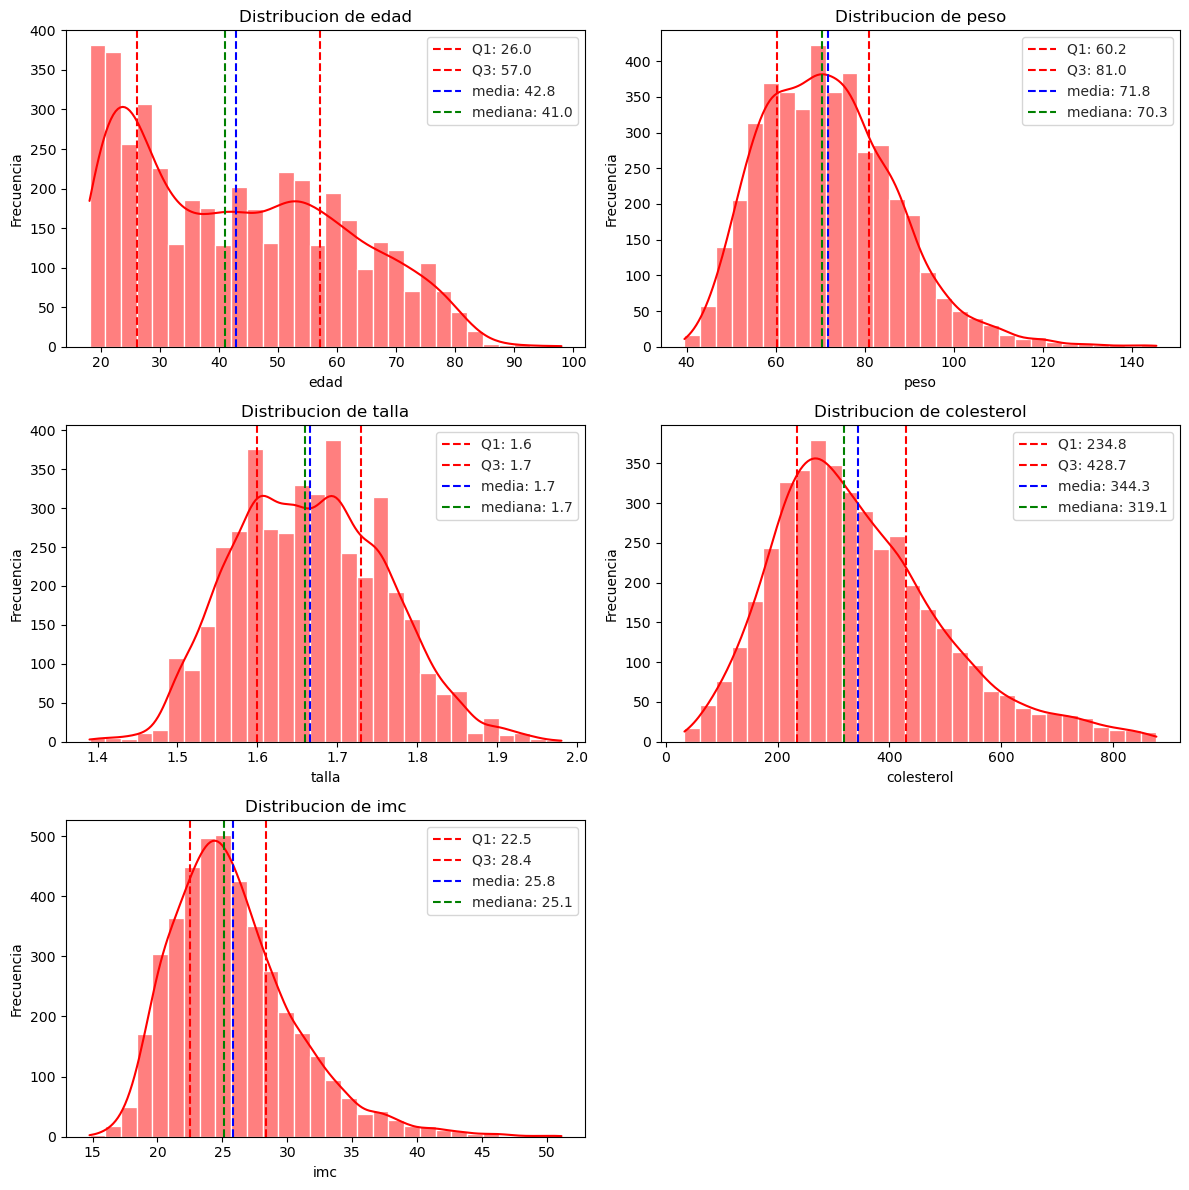

In [29]:
#Visualización 
variables = ['edad', 'peso', 'talla', 'colesterol', 'imc']


fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten() 

sns.set_style("whitegrid")

for i, col in enumerate(variables):
    ax = axes[i]
    
    
    sns.histplot(df_nuevo[col], kde=True, color='red', bins=30, ax=ax)
    
    
    q1 = df_nuevo[col].quantile(0.25)
    q3 = df_nuevo[col].quantile(0.75)
    media = df_nuevo[col].mean()
    mediana = df_nuevo[col].median()
    
    
    ax.axvline(q1, color='red', linestyle='--', label=f'Q1: {q1:.1f}')
    ax.axvline(q3, color='red', linestyle='--', label=f'Q3: {q3:.1f}')
    ax.axvline(media, color='blue', linestyle='--', label=f'media: {media:.1f}')
    ax.axvline(mediana, color='green', linestyle='--', label=f'mediana: {mediana:.1f}')
    

    ax.set_title(f'Distribucion de {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend()

for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [30]:
#Variable categorica-ordinal
moda_imc = df_nuevo['imc_categoria'].mode()
if not moda_imc.empty:
    print("\nMode of imc_categoria:", moda_imc[0])



Mode of imc_categoria: Normal


/tmp/ipykernel_49/4140751132.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_nuevo, x='imc_categoria', order=orden_categorias, palette='Set2')


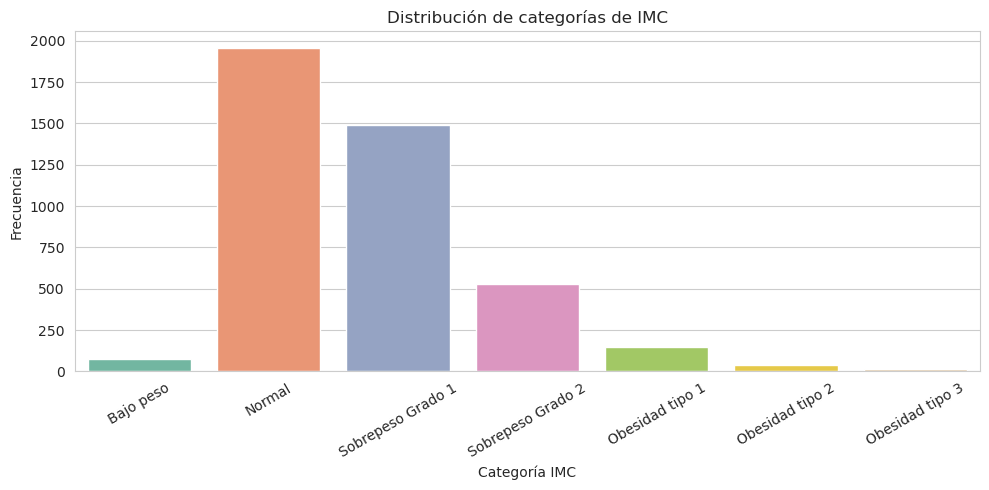

In [31]:
# Visualización 
df_nuevo['imc_categoria'] = pd.cut (
    df_nuevo['imc'],
    bins  = [ 0, 18.5, 24.9, 29.9, 34.9, 39.9, 44.9,  float('inf') ],
    labels = ['Bajo peso', 'Normal', 'Sobrepeso Grado 1', 'Sobrepeso Grado 2', 'Obesidad tipo 1', 'Obesidad tipo 2', 'Obesidad tipo 3' ],
    right = True
    
)

# orden de categorías
orden_categorias = [
    'Bajo peso','Normal','Sobrepeso Grado 1','Sobrepeso Grado 2',
    'Obesidad tipo 1','Obesidad tipo 2','Obesidad tipo 3'
]

# Convertir a categórica ordenada
df_nuevo['imc_categoria'] = pd.Categorical(
    df_nuevo['imc_categoria'],
    categories=orden_categorias,
    ordered=True
)

plt.figure(figsize=(10,5))
sns.countplot(data=df_nuevo, x='imc_categoria', order=orden_categorias, palette='Set2')

plt.title('Distribución de categorías de IMC')
plt.xlabel('Categoría IMC')
plt.ylabel('Frecuencia')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [32]:
#Variable categorica-nominal
variables = ['sexo', 'dbt', 'sedentario'] 

summary = pd.DataFrame({
    'Moda': [df_nuevo[col].mode()[0] if not df_nuevo[col].mode().empty else None for col in variables]
}, index=variables)

print(summary)

            Moda
sexo         2.0
dbt          0.0
sedentario   0.0


/tmp/ipykernel_49/4094473813.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_nuevo, x='sexo_rec', palette='Reds', ax=ax1)
/tmp/ipykernel_49/4094473813.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30)
/tmp/ipykernel_49/4094473813.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_nuevo, x='dbt_rec', palette='Reds', ax=ax2)
/tmp/ipykernel_49/4094473813.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabel

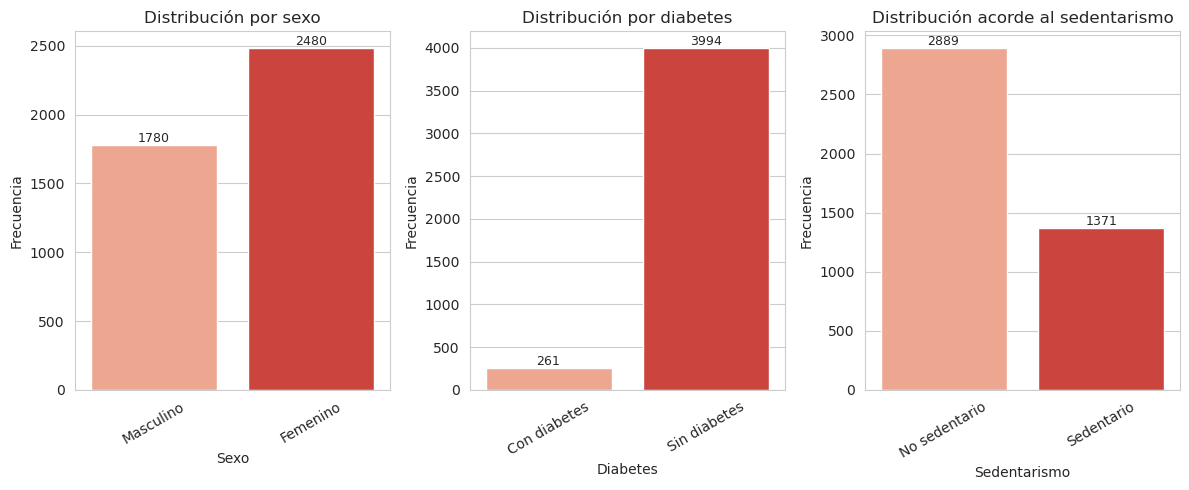

In [33]:
# Visualización 
plt.figure(figsize=(12,5))

# Subplot 1: Sexo
ax1 = plt.subplot(131)
df_nuevo['sexo_rec'] = df_nuevo['sexo'].map({1: 'Masculino', 2: 'Femenino'})
sns.countplot(data=df_nuevo, x='sexo_rec', palette='Reds', ax=ax1)
ax1.set_title('Distribución por sexo')
ax1.set_xlabel('Sexo')
ax1.set_ylabel('Frecuencia')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.0f}",
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=9)

# Subplot 2: Diabetes
ax2 = plt.subplot(132)
df_nuevo['dbt_rec'] = df_nuevo['dbt'].map({0: 'Sin diabetes', 1: 'Con diabetes'})
sns.countplot(data=df_nuevo, x='dbt_rec', palette='Reds', ax=ax2)
ax2.set_title('Distribución por diabetes')
ax2.set_xlabel('Diabetes')
ax2.set_ylabel('Frecuencia')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30)

for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.0f}",
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=9)

# Subplot 3: Sedentarismo
ax3 = plt.subplot(133)
df_nuevo['sedentario_rec'] = df_nuevo['sedentario'].map({0: 'No sedentario', 1: 'Sedentario'})
sns.countplot(data=df_nuevo, x='sedentario_rec', palette='Reds', ax=ax3)
ax3.set_title('Distribución acorde al sedentarismo')
ax3.set_xlabel('Sedentarismo')
ax3.set_ylabel('Frecuencia')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=30)

for p in ax3.patches:
    ax3.annotate(f"{p.get_height():.0f}",
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### Outliers

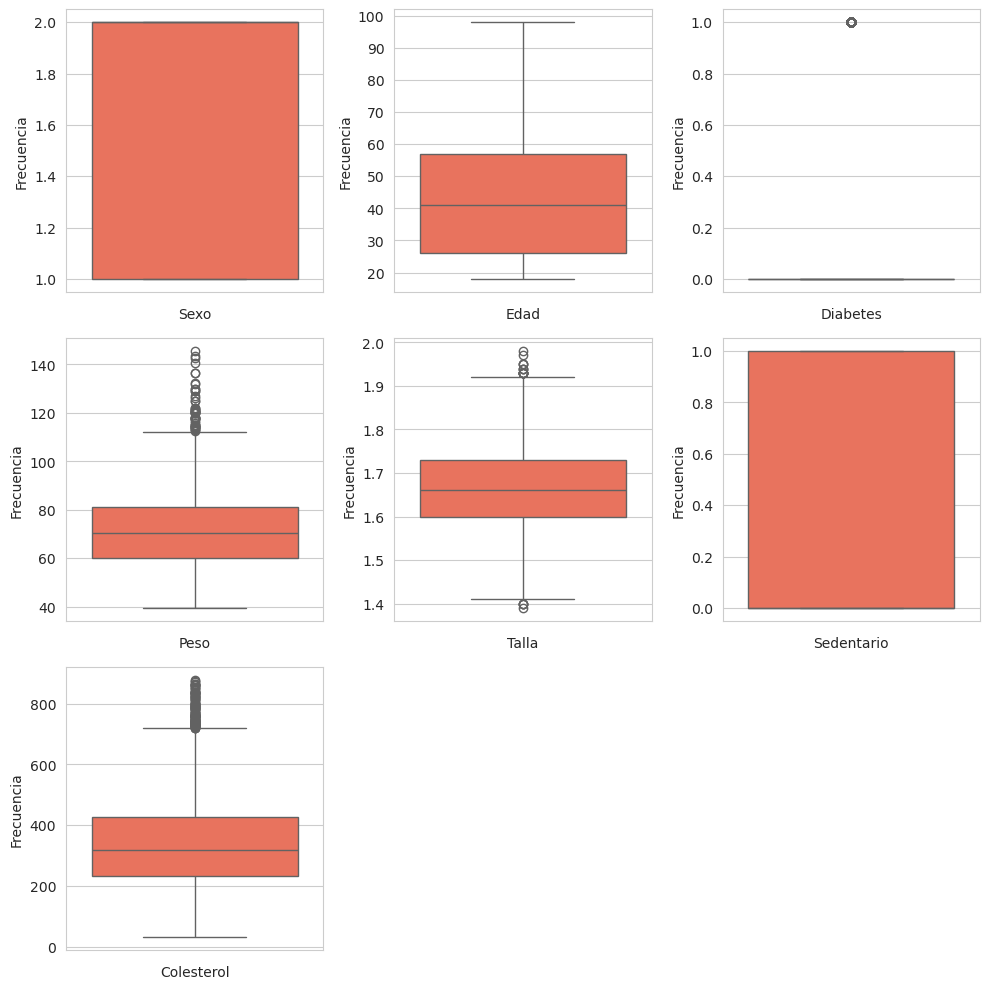

In [34]:
# Visualización mediante boxplot
plt.figure(figsize=(10,10))

plt.subplot(331)
sns.boxplot (df_nuevo['sexo'], color='tomato')
plt.xlabel ('Sexo')
plt.ylabel('Frecuencia')

plt.subplot(332)
sns.boxplot (df_nuevo['edad'], color='tomato')
plt.xlabel ('Edad')
plt.ylabel('Frecuencia')

plt.subplot(333)
sns.boxplot (df_nuevo['dbt'], color='tomato')
plt.xlabel ('Diabetes')
plt.ylabel('Frecuencia')

plt.subplot(334)
sns.boxplot (df_nuevo['peso'], color='tomato')
plt.xlabel ('Peso')
plt.ylabel('Frecuencia')

plt.subplot(335)
sns.boxplot (df_nuevo['talla'], color='tomato')
plt.xlabel ('Talla')
plt.ylabel('Frecuencia')

plt.subplot(336)
sns.boxplot (df_nuevo['sedentario'], color='tomato')
plt.xlabel ('Sedentario')
plt.ylabel('Frecuencia')

plt.subplot(337)
sns.boxplot (df_nuevo['colesterol'], color='tomato')
plt.xlabel ('Colesterol')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

3.2. Análisis de outliers/valores atípicos

No se observan valores atípicos en esta instancia debido a que los mismos ya fueron tratados anteriormente. 

### 4) Análisis bivariado e inferencial:
*   4.1. Seleccionar una variable respuesta (target) y analizar su relación con al menos dos variables independientes de distinta naturaleza (una numérica y una categórica).

In [35]:
df_nuevo

,id,sexo,edad,dbt,peso,talla,sedentario,colesterol,imc,imc_categoria,sexo_rec,dbt_rec,sedentario_rec
0,11.0,1.0,52.0,1.0,115.099998,1.82,0,281.089996,34.748219,Sobrepeso Grado 2,Masculino,Con diabetes,No sedentario
1,2982.0,2.0,45.0,0.0,68.699997,1.70,1,266.230011,23.771624,Normal,Femenino,Sin diabetes,Sedentario
2,1014.0,1.0,25.0,0.0,65.199997,1.74,0,163.279999,21.535208,Normal,Masculino,Sin diabetes,No sedentario
3,2536.0,2.0,25.0,0.0,80.199997,1.68,0,245.369995,28.415533,Sobrepeso Grado 1,Femenino,Sin diabetes,No sedentario
4,287.0,1.0,72.0,0.0,73.099998,1.74,0,115.660004,24.144537,Normal,Masculino,Sin diabetes,No sedentario
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4323,4154.0,2.0,64.0,0.0,65.500000,1.56,1,365.239990,26.914862,Sobrepeso Grado 1,Femenino,Sin diabetes,Sedentario
4324,4269.0,2.0,58.0,0.0,60.500000,1.64,0,256.079987,22.494051,Normal,Femenino,Sin diabetes,No sedentario
4325,4229.0,2.0,65.0,0.0,79.000000,1.68,1,334.589996,27.990364,Sobrepeso Grado 1,Femenino,Sin diabetes,Sedentario
4326,4132.0,2.0,38.0,0.0,59.000000,1.65,1,198.009995,21.671259,Normal,Femenino,Sin diabetes,Sedentario


### Análisis de variable Continua

Para ambos análisis se toma como tarjet la variable diabetes. 

En esta instancia se toma como variable numérica a 'imc'.

In [36]:
#Se aplica Kolmogorov–Smirnov (KS)  para observar la distribución ya que el tamaño de la muestra es > 50

stat, p_value = stats.kstest(df_nuevo['imc'], 'norm' )
print(f" KS statistic: {stat:.3f}, p-value: {p_value:.3f}")

 KS statistic: 1.000, p-value: 0.000


Se rechaza la hipótesis nula dado que p < 0.05 y por ende, la variable 'imc' no se distribuye de forma normal. 
A pesar de no presentar una distribución normal, al ser el -_n muestral_ grande, se decide aplicar la prueba de hipótesis T-Student para muestras independientes a fin de comparar si existen diferencias significativas en la variable 'imc' entre las personas que presentan diabetes ( _n_ = 261) y aquellas que no presentan esta condición ( _n_ = 3999). 

In [37]:
#T Student
def comparar_grupos_final(df_nuevo, variable="imc", grupo="dbt_rec",
                         valor_grupo1='Con diabetes', valor_grupo2='Sin diabetes'):

    # Separar grupos 
    g1 = df_nuevo[df_nuevo[grupo] == valor_grupo1][variable].dropna()
    g2 = df_nuevo[df_nuevo[grupo] == valor_grupo2][variable].dropna()

    #Welch t-test 
    stat, p_value = stats.ttest_ind(g1, g2, equal_var=False)

    # Estadísticos básicos 
    mean1, mean2 = np.mean(g1), np.mean(g2)
    std1, std2 = np.std(g1, ddof=1), np.std(g2, ddof=1)
    n1, n2 = len(g1), len(g2)

    # Cohen’s d 
    pooled_std = np.sqrt(((n1 - 1)*std1**2 + (n2 - 1)*std2**2) / (n1 + n2 - 2))
    cohen_d = (mean1 - mean2) / pooled_std

    # Interpretación de Cohen’s d 
    if abs(cohen_d) < 0.2:
        magnitud = "Muy pequeño"
    elif abs(cohen_d) < 0.5:
        magnitud = "Pequeño"
    elif abs(cohen_d) < 0.8:
        magnitud = "Moderado"
    else:
        magnitud = "Grande"

    # Interpretación del p-valor
    if p_value < 0.05:
        conclusion = "Diferencia estadísticamente significativa"
    else:
        conclusion = "No se observa diferencia significativa"

    # Resultado
    resultado = pd.DataFrame({
        "Grupo 1 (media)": [round(mean1, 2)],
        "Grupo 2 (media)": [round(mean2, 2)],
        "t-stat": [round(stat, 3)],
        "p-valor": [round(p_value, 5)],
        "Cohen's d": [round(cohen_d, 3)],
        "Magnitud efecto": [magnitud],
        "Conclusión": [conclusion]
    })

    return resultado

In [38]:
comparar_grupos_final(df_nuevo)

,Grupo 1 (media),Grupo 2 (media),t-stat,p-valor,Cohen's d,Magnitud efecto,Conclusión
0,30.07,25.57,12.805,0.0,0.961,Grande,Diferencia estadísticamente significativa


Como se observa en los resultados, el grupo que presenta la condición (Con diabetes - grupo 1) Obtuvo una puntuación de 'imc' (_M_ = 30.07) significativamente mayor (p < 0.05) respecto al 'imc' del grupo sin la condición (Sin diabetes - grupo 2). A este último le corresponde un _M_ = 25.57 . Adicionalmente, se calculó el tamaño del efecto (Cohen's $d$) para evaluar la magnitud de esta diferencia. Se encontró un efecto grande con una $d$ de Cohen de 0.961, lo que indica que el grupo con diabetes presenta un IMC superior al grupo que no presenta la condición. 

Finalmente, se _acepta_ la hipótesis alternativa: 'El grupo con diabetes presenta un índice de masa corporal significativamente mayor respecto de aquellos que no presentan esta condición.'

Este resultado coincide con estudios previos que han indicado que un valor de 'imc' elevado con el riesgo de padecer diabetes. 

#### Visualización 

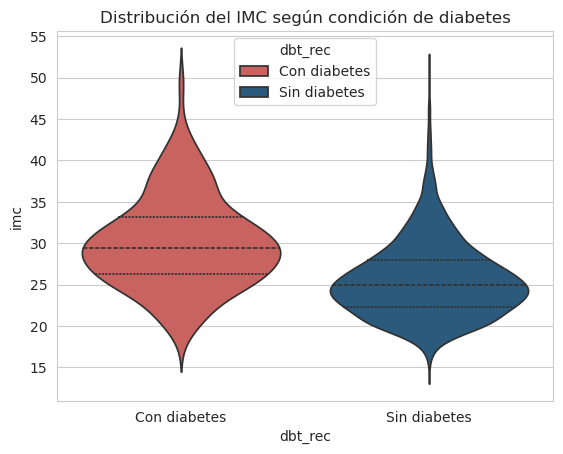

In [40]:
# Violin plot por Diabetes
colores_azules = ["#d9534f", "#1d5c8a"]
sns.violinplot(
    data=df_nuevo,
    x='dbt_rec',          # eje X: condición de diabetes
    y='imc',              # eje Y: IMC
    inner='quartile',     # muestra cuartiles dentro del violín
    hue='dbt_rec',        # color por grupo
    palette=colores_azules        # paleta de colores
)

plt.title("Distribución del IMC según condición de diabetes")
plt.show()



### Análisis de variable Categórica

En esta instancia se toma como variable categórica a 'sedentarismo'.

In [41]:
table = pd.crosstab(df_nuevo['dbt_rec'], df_nuevo['sedentario_rec'])
table 

sedentario_rec,No sedentario,Sedentario
dbt_rec,,
Con diabetes,210,51
Sin diabetes,2675,1319


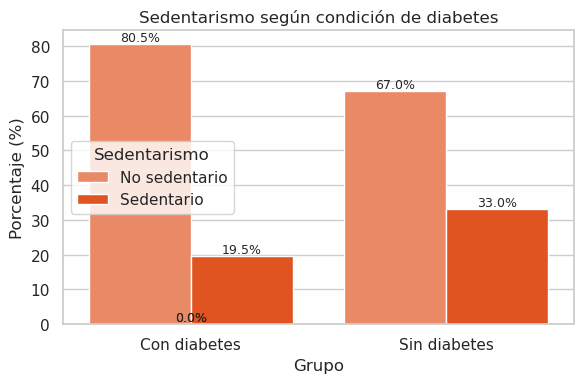

In [42]:
# Datos de la tabla
data = {
    "Grupo": ["Con diabetes", "Con diabetes", "Sin diabetes", "Sin diabetes"],
    "sedentario_rec": ["No sedentario", "Sedentario", "No sedentario", "Sedentario"],
    "count": [210, 51, 2679, 1320]
}
df = pd.DataFrame(data)

# Calcular porcentajes dentro de cada grupo
df["total_grupo"] = df.groupby("Grupo")["count"].transform("sum")
df["porcentaje"] = (df["count"] / df["total_grupo"]) * 100

# Gráfico de barras con paleta lilas
sns.set(style="whitegrid")
palette_lilas = ["#FF7F50", '#FF4500']  # tonos lilas

plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=df,
    x="Grupo",
    y="porcentaje",
    hue="sedentario_rec",
    palette=palette_lilas
)

# Etiquetas y título
ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Grupo")
ax.set_title("Sedentarismo según condición de diabetes")

# Mostrar porcentajes sobre las barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.legend(title="Sedentarismo")
plt.tight_layout()
plt.show()

In [43]:
# Chi Cuadradro

from scipy.stats import chi2_contingency

table = pd.crosstab(df_nuevo['dbt_rec'], df_nuevo['sedentario_rec'])
n = table.sum().sum()

chi2, p_value, __, __ = chi2_contingency(table)
Cramer_v = np.sqrt (chi2 / (n *(min(table.shape)-1)))

print(f'Chi-square: { round(chi2, 3)}')
print(f'p-value (Chi2): {round(p_value, 4)}')
print(f'Cramér’s V: { round(Cramer_v, 3)}')

Chi-square: 19.792
p-value (Chi2): 0.0
Cramér’s V: 0.068


Como se observa a través de la tabla de contingencia y el gráfico de barra, el porcentaje de personas con diabetes que son sedentarias (19.5%) es significativamente _menor_ (χ² = 19.75; p < 0.05; V  =  0.068) al porcentaje de aquellas que tienen diabetes y realizan actividad física (no sedentarias) (80.5%). 

A su vez, las personas con ausencia de esta condición presentan un comportamiento similar respecto al primer grupo mencionado. 

A pesar de la significancia estadística, la magnitud de la asociación, medida por la V de Cramer, fue 0.068, lo que sugiere un tamaño del efecto bajo/pequeño. Por lo tanto, aunque la asociación existe, el sedentarismo podría no ser un factor determinante en la presencia de diabetes.

Se acepta por tanto la hipótesis alternativa donde la proporción de persona con diabetes que realizan actividad física es significativamente mayor a las personas con diabetes que _no_ realizan actividad física.

En esta muestra estudiada, una posible explicación de esta hipótesis es que las personas con diabetes que participaron del estudio se encontraban en un tratamiento donde en parte se les pedía que realicen actividad física. 
Por su parte, surge la duda de la frecuencia semanal de la misma, el tipo (aeróbico, de fuerza, resistencia) además de la intensidad. Si esto último estuviese más claro, se podría entender el por qué de los resultados y evaluar desde otra perspectiva. 

In [44]:
df_nuevo['sexo_rec'] = df_nuevo['sexo_rec'].map ({'Masculino' : 1 , 'Femenino' : 0})

## Modelo Predictivo


In [45]:
df_nuevo

,id,sexo,edad,dbt,peso,talla,sedentario,colesterol,imc,imc_categoria,sexo_rec,dbt_rec,sedentario_rec
0,11.0,1.0,52.0,1.0,115.099998,1.82,0,281.089996,34.748219,Sobrepeso Grado 2,1,Con diabetes,No sedentario
1,2982.0,2.0,45.0,0.0,68.699997,1.70,1,266.230011,23.771624,Normal,0,Sin diabetes,Sedentario
2,1014.0,1.0,25.0,0.0,65.199997,1.74,0,163.279999,21.535208,Normal,1,Sin diabetes,No sedentario
3,2536.0,2.0,25.0,0.0,80.199997,1.68,0,245.369995,28.415533,Sobrepeso Grado 1,0,Sin diabetes,No sedentario
4,287.0,1.0,72.0,0.0,73.099998,1.74,0,115.660004,24.144537,Normal,1,Sin diabetes,No sedentario
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4323,4154.0,2.0,64.0,0.0,65.500000,1.56,1,365.239990,26.914862,Sobrepeso Grado 1,0,Sin diabetes,Sedentario
4324,4269.0,2.0,58.0,0.0,60.500000,1.64,0,256.079987,22.494051,Normal,0,Sin diabetes,No sedentario
4325,4229.0,2.0,65.0,0.0,79.000000,1.68,1,334.589996,27.990364,Sobrepeso Grado 1,0,Sin diabetes,Sedentario
4326,4132.0,2.0,38.0,0.0,59.000000,1.65,1,198.009995,21.671259,Normal,0,Sin diabetes,Sedentario


En el contexto de interés, la variable de salida (como tener diabetes) es dicotómica (tiene o no tiene), el modelo logístico es el adecuado para utilizar las variables independientes seleccionadas (IMC, colesterol, sexo, sedentarismo, edad) y calcular las probabilidades de padecer la enfermedad. Antes de aplicar el modelo multivariable con todas las variables, es necesario realizar un pre-procesamiento de datos para codificar las variables dicotómicas (como el sexo o la presencia de diabetes) en números (0 y 1) para que el modelo pueda interpretarlas.

## Pre-procesamiento
Para facilitar el flujo de trabajo, es mejor trabajar con valores de tipo _int/float_ en lugar de strings. Sin embargo, las variables como _sexo y sedentario_ ya presentan una codificación binaria (1/0). 

Por su parte, para el modelo de regresión logística conviene utilizar el IMC (la variable numérica continua) en lugar del IMC ya clasificado (la variable categórica). Esto se debe a que el IMC, al ser una variable continua, conserva toda la información y la variación individual de los datos. Por tanto, usar una variable de este tipo ofrece mayor poder estadístico y predictivo, permitiendo al modelo detectar una relación más precisa entre el aumento gradual del IMC y la probabilidad de padecer diabetes. 

El mismo criterio, se toma para _colesterol y edad._ Las mismas no serán transformadas a categóricas para mantener la información y la variación individual de los datos. 

## Regresión logística

In [56]:
X_log = df_nuevo[['sexo', 'sedentario', 'colesterol', 'imc', 'edad']]
y_log = df_nuevo ['dbt']

X_log = sm.add_constant(X_log)

modelo_log = sm.Logit(y_log, X_log).fit()

print (modelo_log.summary())

ValueError: endog must be in the unit interval.

## Odd Ratio

In [47]:
OR = np.exp (modelo_log.params)

print ('\nOdds Ratio: ')
print (OR)

NameError: name 'modelo_log' is not defined

El _odds ratios (OR)_ mide cuánto cambian las odds de tener la enfermedad (evento = 1) según la presencia o el valor de cada variable, comparado con el grupo de referencia. 

OR = 1 → no hay efecto (las odds son iguales en ambos grupos).

OR > 1 → la variable aumenta las odds del evento (factor de riesgo).

OR < 1 → la variable disminuye las odds del evento (factor protector).

_Ejemplo_
OR < 1	El sexo masculino (Categoría 1) es un factor de protección. El odds de tener diabetes es menor para los hombres que para las mujeres.

In [48]:
coef_log = modelo_log.params

ecuacion_log = f"logit(p) = {coef_log['const']:.4f}"

for var in ['sexo', 'sedentario', 'colesterol', 'imc', 'edad']:
    ecuacion_log += f" + ({coef_log[var]:.4f} * {var})"

print("\nModelo logístico:")
print(ecuacion_log) #fórmula del modelo logístico 

NameError: name 'modelo_log' is not defined

In [49]:
#Valores del paciente
edad = 23
sexo = 0 #1: M 0: F
sedentario = 0 #1: Sí sedentario 0: NO sedentario
colesterol = 214
imc = 24.6

# coeficientes del modelo
coef = modelo_log.params

# Armo la ecuacion
logit = (
    coef["const"]
    + coef["edad"] * edad
    + coef["sexo"] * sexo
    + coef["sedentario"] * sedentario
    + coef["colesterol"] * colesterol
    + coef["imc"] * imc
)

# transformación logística → probabilidad
prob = 1 / (1 + np.exp(-logit))

# impresión clara
print("Modelo logístico (coeficientes reales):")
print(
    f"logit(p) = {coef['const']:.6f} + "
    f"({coef['edad']:.6f} * edad) + "
    f"({coef['sexo']:.6f} * sexo) + "
    f"({coef['sedentario']:.6f} * sedentario)"
    f"({coef['colesterol']:.6f} * colesterol)"
    f"({coef['imc']:.6f} * imc)"
)


print("\nPaciente evaluado:")
print(f"edad = {edad}, sexo = {sexo}, sedentario = {sedentario}, colesterol = {colesterol}, imc = {imc}")

print("\nResultados:")
print(f"logit(p) = {logit:.6f}")
print(f"probabilidad = {prob:.6f}")

NameError: name 'modelo_log' is not defined

## Curva ROC-AUC

In [50]:
from sklearn.metrics import roc_auc_score, roc_curve

# Probabilidades predichas por tu modelo
probs = modelo_log.predict(X_log)

# Calcular AUC
auc = roc_auc_score(y_log, probs)
print(f"AUC del modelo: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_log, probs)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="tomato")
plt.plot([0,1],[0,1], linestyle="--", color="gray")  # línea azar
plt.xlabel("1 - Especificidad (FPR)")
plt.ylabel("Sensibilidad (TPR)")
plt.title("Curva ROC del modelo logístico")
plt.legend()
plt.show()

NameError: name 'modelo_log' is not defined

| Rango de AUC | Capacidad de Discriminación |
|--------------|-----------------------------|
| 0.7 – 0.8    | Aceptable                   |
| 0.8 – 0.9    | Excelente                   |
| > 0.9        | Sobresaliente               |


Este valor AUC = 0.802 (AUC: Area Under the Curve), según las métricas estándar, indica que el modelo tiene una excelente capacidad diagnóstica para predecir la probabilidad de tener diabetes. Por lo tanto significa que el modelo es eficaz para distinguir entre individuos con y sin la condición.

## Sensibilidad - Especificidad del Modelo

In [51]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Probabilidades del modelo
probs = modelo_log.predict(X_log)

# thresholds a evaluar
thresholds = np.linspace(0, 1, 100)

resultados = []

for t in thresholds:
    y_pred = (probs >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_log, y_pred).ravel()

    sensibilidad = tp / (tp + fn)
    especificidad = tn / (tn + fp)

    diff = abs(sensibilidad - especificidad)

    resultados.append((t, sensibilidad, especificidad, diff))

# convertir a array
resultados = np.array(resultados)

# encontrar el mejor threshold (mínima diferencia)
best_idx = np.argmin(resultados[:, 3])

best_threshold = resultados[best_idx, 0]
best_sens = resultados[best_idx, 1]
best_spec = resultados[best_idx, 2]

print(f"Threshold óptimo: {best_threshold:.3f}")
print(f"Sensibilidad: {best_sens:.3f}")
print(f"Especificidad: {best_spec:.3f}")

NameError: name 'modelo_log' is not defined

In [52]:
sens = resultados[:, 1]
spec = resultados[:, 2]

plt.plot(thresholds, sens, label="Sensibilidad")
plt.plot(thresholds, spec, label="Especificidad")

plt.axvline(best_threshold, linestyle="--", color="black", label=f"Threshold óptimo = {best_threshold:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Valor")
plt.title("Sensibilidad vs Especificidad")

plt.legend()
plt.show()

NameError: name 'resultados' is not defined

Los valores de sensibilidad y especificidad del modelo de regresión logística son:

- Sensibilidad (Capacidad para detectar casos positivos):
   Es del 72% (casi 73%). Esto significa que el modelo clasificó correctamente a casi el 73% de las personas que realmente tienen diabetes.
  
- Especificidad (Capacidad para detectar casos negativos):
  Es del 74%. Esto indica que el modelo clasificó correctamente al 74% de las personas que realmente no tienen diabetes.
  
El umbral óptimo se encuentra en el punto de cruce entre la sensibilidad y la especificidad. Dado que ambos valores están por encima del 70%, se concluye que el modelo tiene una buena capacidad diagnóstica.

## Tasa de Aciertos

In [53]:
accuracy = (tp + tn) / (tp + tn + fn + fp)
print (f'Tasa de aciertos: {accuracy: .3f}')

NameError: name 'tp' is not defined

Esto significa que el número de predicciones correctas sobre las predicciones totales es del 94%. 

Un Accuracy muy alto, especialmente en bases de datos desequilibradas (donde hay muchos más casos "sanos" que "enfermos"), puede significar que el modelo está siendo muy bueno para clasificar los casos negativos (los "sanos") y no está detectando eficazmente los casos positivos (los "enfermos") que es lo que se observa en este caso. 

In [54]:
#Exporto los datos
df_nuevo.to_excel("datos.xlsx", index=False, engine="openpyxl")

In [55]:
df_nuevo.info()

<class 'pandas.DataFrame'>
Index: 4260 entries, 0 to 4327
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   id              4260 non-null   float64 
 1   sexo            4260 non-null   float64 
 2   edad            4260 non-null   float64 
 3   dbt             4255 non-null   float64 
 4   peso            4260 non-null   float32 
 5   talla           4260 non-null   float32 
 6   sedentario      4260 non-null   int8    
 7   colesterol      4260 non-null   float32 
 8   imc             4260 non-null   float32 
 9   imc_categoria   4260 non-null   category
 10  sexo_rec        4260 non-null   int64   
 11  dbt_rec         4255 non-null   str     
 12  sedentario_rec  4260 non-null   str     
dtypes: category(1), float32(4), float64(4), int64(1), int8(1), str(2)
memory usage: 442.5 KB
